# Dimensionality Reduction - t-SNE and UMAP - A Simple Coding Tutorial #


In this coding tutorial we will demonstrate the use of 't-SNE' and 'UMAP' dimensionality reduction methods. We will compare their results with each other and also with the linear dimensionality reduction method of 'PCA' which we discussed in a previous article.


## 1) Create a simple high-dimensional dataset ##

We will first start by creating a simple high-dimensional dataset for our tutorial.


In [ ]:
# If required, uncomment the below line and install the necessary libraries

# pip install numpy matplotlib scikit-learn umap-learn

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs            # to help create synthetic clustered data
from sklearn.preprocessing import StandardScaler   # for normalizing features
from sklearn.decomposition import PCA              # linear baseline method
from sklearn.manifold import TSNE
import umap                                        # nonlinear dimensionality reduction

Now, we create a simple high-dimensional dataset:

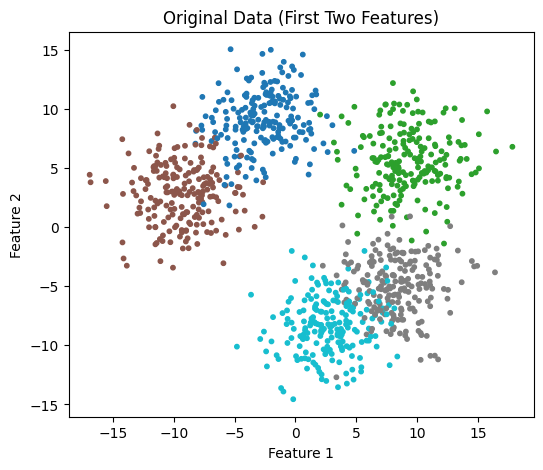

In [ ]:
X, y = make_blobs(
    n_samples=1000,
    n_features=50,
    centers=5,
    cluster_std=2.5,
    random_state=42
)

# Visualize with first two feature
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=10)
plt.title("Original Data (First Two Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


'X' is high-dimensional (1000x50)
and 'y' are the ground-truth cluster labels

Next, we standardize the data. Since t-SNE and UMAP are distance based, scaling is very important, because without normalization, features with large variation dominate the distances.

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 2) PCA - Principal Component Analysis ##

Now, we first use the baseline method of PCA.

As you can remember, PCA helps in removing noise from the data and will provide a linear comparison for use during this tutorial.

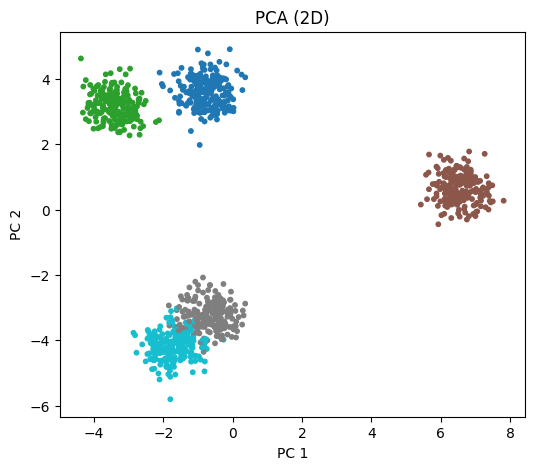

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=10)
plt.title("PCA (2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


It can be observed that there is some cluster seperation, an overlapping group is present and most importantly only linear structure is captured by the two principal components through PCA.

## 3) t-SNE ##

Next, we apply the method o ft-SNE directly to the scaled dataset.

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)


Key parameters:

*Perplexity*: neighborhood size (from 5-50)

*learning_rate*: this parameter can affect the convergence of the model

*max_iter*: number of optimization steps

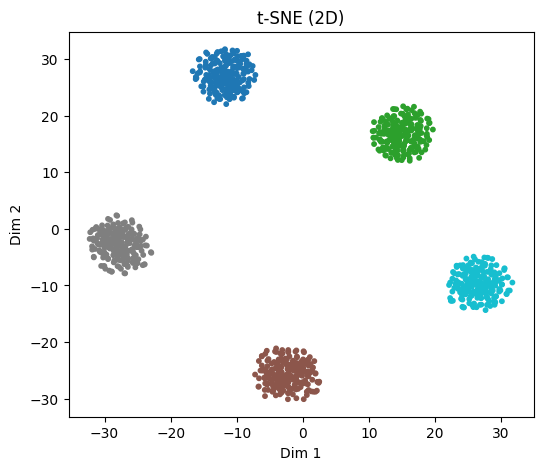

In [ ]:
# Visualize t-SNE

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="tab10", s=10)
plt.title("t-SNE (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


From the t-SNE visualization it can be clearly observed that we now have clusters that appear clearly seperated and excellent preservation of the local structure is achieved.

## 4) UMAP ##

Next, we apply the method of UMAP to the same scaled dataset.

In [ ]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Key parameters:

*n_neighbors*: determines local vs global balance

*min_dist*: determines how tightly the datapoints are packed

*n_components*: output dimension


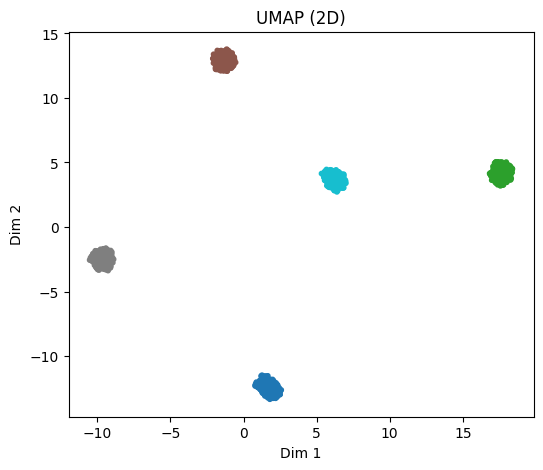

In [ ]:
# Visualize UMAP

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="tab10", s=10)
plt.title("UMAP (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


It can be observed that UMAP achieves more clear clusters and better global organization than PCA and t-SNE.

Next, lets visualize the results of these methods side by side.

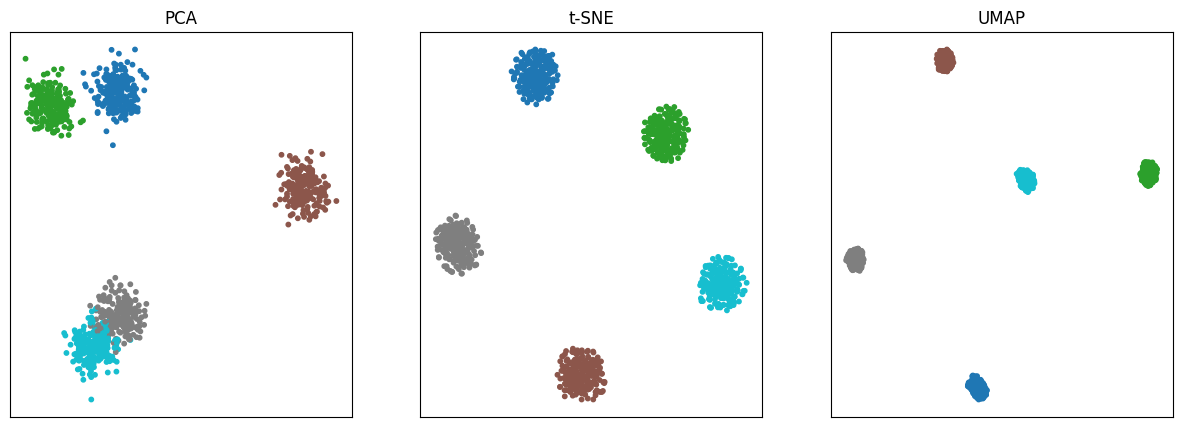

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=10)
axes[0].set_title("PCA")

axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="tab10", s=10)
axes[1].set_title("t-SNE")

axes[2].scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="tab10", s=10)
axes[2].set_title("UMAP")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


## What do the results demonstrate? ##

PCA:
* Preserves variance
* Poor at nonlinear seperation
* Fast and interpretable

t-SNE:
* Excellent local clustering
* Distances between clusters can be meaningless

UMAP:
* Preserves local + some global structure
* Fast and scalable

## Conclusion ##

t-SNE and UMAP are mostly used as visualization tools by performing dimensionality reduction. They help us see structure in high-dimensional data that would otherwise remain hidden.

Together with PCA, these nonlinear methods form a powerful toolbox for understanding modern machine learning representations.

And in the end we suggest to try running this notebook again by changing the parameters of each method and experimenting to understand how the results change, this can give you more insight into how each method affects the scaled data in its own way.

Good luck!